<a href="https://colab.research.google.com/github/mrabinayaa/DAAexps/blob/main/exp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

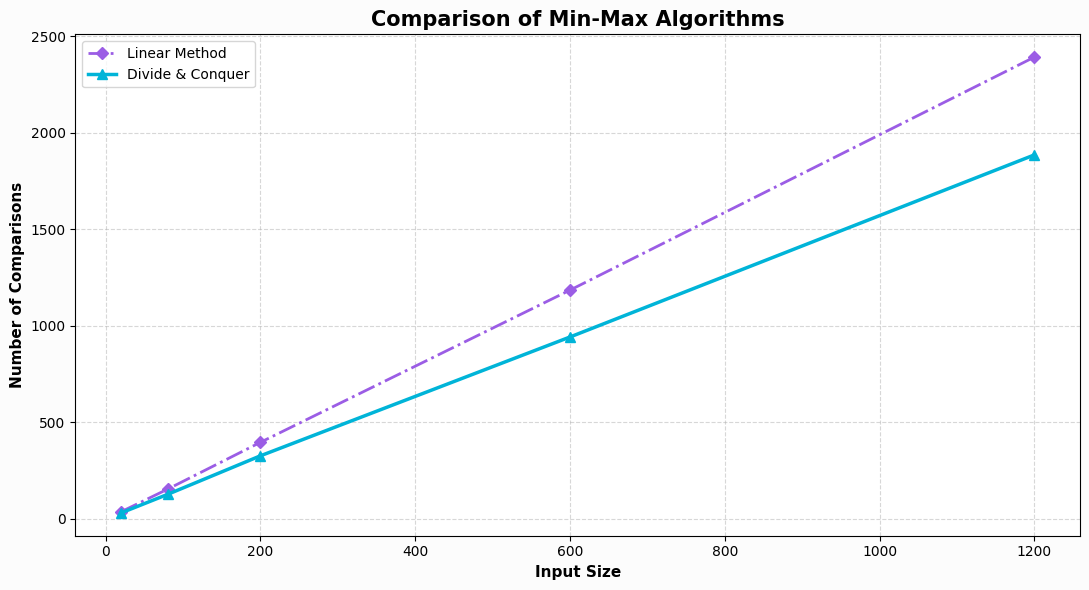

In [1]:
import random
import matplotlib.pyplot as plt

# -------------------- Divide & Conquer --------------------

def find_minmax(arr, left, right):

    if left == right:
        return arr[left], arr[left], 0

    if right == left + 1:
        if arr[left] < arr[right]:
            return arr[left], arr[right], 1
        else:
            return arr[right], arr[left], 1

    middle = (left + right) // 2

    min1, max1, comp1 = find_minmax(arr, left, middle)
    min2, max2, comp2 = find_minmax(arr, middle + 1, right)

    minimum = min1 if min1 < min2 else min2
    maximum = max1 if max1 > max2 else max2

    total = comp1 + comp2 + 2

    return minimum, maximum, total


# -------------------- Iterative Method --------------------

def linear_minmax(arr):

    minimum = maximum = arr[0]
    comparisons = 0

    for value in arr[1:]:

        comparisons += 1

        if value < minimum:
            minimum = value
        else:
            comparisons += 1

            if value > maximum:
                maximum = value

    return minimum, maximum, comparisons


# -------------------- Benchmark --------------------

array_sizes = [20, 80, 200, 600, 1200]

linear_result = []
divide_result = []

for size in array_sizes:

    numbers = [random.randint(100, 50000) for _ in range(size)]

    _, _, c1 = linear_minmax(numbers)
    _, _, c2 = find_minmax(numbers, 0, len(numbers)-1)

    linear_result.append(c1)
    divide_result.append(c2)


# -------------------- Visualization --------------------

plt.figure(figsize=(11,6), facecolor="#FCFCFC")

plt.plot(
    array_sizes,
    linear_result,
    marker="D",
    markersize=6,
    linewidth=2,
    linestyle="-.",
    color="#9B5DE5",
    label="Linear Method"
)

plt.plot(
    array_sizes,
    divide_result,
    marker="^",
    markersize=7,
    linewidth=2.5,
    linestyle="-",
    color="#00B4D8",
    label="Divide & Conquer"
)

plt.title(
    "Comparison of Min-Max Algorithms",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Input Size",
    fontsize=11,
    fontweight="bold"
)

plt.ylabel(
    "Number of Comparisons",
    fontsize=11,
    fontweight="bold"
)

plt.grid(
    linestyle="--",
    alpha=0.5
)

plt.legend(
    loc="upper left",
    fontsize=10
)

plt.tight_layout()
plt.show()